# Credit risk modelling using Logistic Regression
## PRASHANTH KANNADAGULI
### SR. DATA SCIENCE TRAINER

## Problem Statement

Predict the loan defaulters using a Logistic Regression model on the credit risk data and calculate credit scores

## Learning Objectives

At the end of the mini-project, you will be able to :

* perform data exploration, preprocessing and visualization
* implement Logistic Regression using manual code or using sklearn library
* evaluate the model using appropriate performance metrics
* develop a credit scoring system

## Dataset

The dataset chosen for this mini-project is the [Give Me Some Credit](https://cdn.iisc.talentsprint.com/CDS/Give_me_some_credit_BigML.pdf) dataset which can be used to build models for predicting loan repayment defaulters
#### Datafields

- **SeriousDlqin2yrs:** Person experienced 90 days past due delinquency or worse
- **RevolvingUtilizationOfUnsecuredLines:** Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits
- **age:** Age of borrower in years
- **NumberOfTime30-59DaysPastDueNotWorse:** Number of times borrower has been 30-59 days past due but no worse in the last 2 years.
- **DebtRatio:** Monthly debt payments, alimony,living costs divided by monthy gross income
- **MonthlyIncome:** Monthly income
- **NumberOfOpenCreditLinesAndLoans:** Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards)
- **NumberOfTimes90DaysLate:** Number of times borrower has been 90 days or more past due.
- **NumberRealEstateLoansOrLines:**	Number of mortgage and real estate loans including home equity lines of credit
- **NumberOfTime60-89DaysPastDueNotWorse:**	Number of times borrower has been 60-89 days past due but no worse in the last 2 years.
- **NumberOfDependents:** Number of dependents in family excluding themselves (spouse, children etc.)

## Information

Credit risk arises when a corporate or individual borrower fails to meet their debt obligations. From the lender's perspective, credit risk could disrupt its cash flows or increase collection costs, since the lender may be forced to hire a debt collection agency to enforce the collection. The loss may be partial or complete, where the lender incurs a loss of part of the loan or the entire loan extended to the borrower.

Credit scoring algorithms, which calculate the probability of default, are the best methods that banks use to determine whether or not a loan should be granted.

In order to build a credit scoring system, the following feature transformations are performed:

#### Weight of Evidence and Information value

Logistic regression is a commonly used technique in credit scoring for solving binary classification problems. Prior to model fitting, another iteration of variable selection is valuable to check if the newly WOE transformed variables are still good model candidates. Preferred candidate variables are those with higher information value having a linear relationship with the dependent variable, have good coverage across all categories, have a normal distribution, contain a notable overall contribution, and are relevant to the business.

**Weight of evidence** (WOE) is a powerful tool for feature representation and evaluation in data science. WOE can provide interpret able transformation to both categorical and numerical features. The weight of evidence tells the predictive power of an independent variable in relation to the dependent variable. Since it evolved from credit scoring world, it is generally described as a measure of the separation of good and bad customers. "Bad Customers" refers to the customers who defaulted on a loan. and "Good Customers" refers to the customers who paid back loan. WOE can be calculated using the below formula:

$$WOE = ln \left( \frac{\%   of  Non\_Events}{\%   of  Events} \right)$$

Steps to calculate WOE
* For a continuous variable, split data into 10 parts (or lesser depending on the distribution).
* Calculate the number of events and non-events in each group (bin)
* Calculate the % of events and % of non-events in each group.
* Calculate WOE by taking natural log of division of % of non-events and % of events

**Information value** is one of the most useful technique to select important variables in a predictive model. It helps to rank variables on the basis of their importance. The IV is calculated using the following formula :
$$IV = ∑ (\% of Non\_Events - \% of Events) * WOE$$

Read more about `WOE` and `IV` from the following [link](https://medium.com/@yanhuiliu104/credit-scoring-scorecard-development-process-8554c3492b2b)

### Download the xverse

In [1]:

!pip -qq install xverse


### Import Neccesary Packages

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sns
from matplotlib import pyplot as plt
import math
from xverse.transformer import MonotonicBinning,WOE
%matplotlib inline

### Load the dataset

In [3]:
cred = pd.read_csv("GiveMeSomeCredit.csv")

#### Describe the all statistical properties of the train dataset

In [4]:
cred.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


### Pre-processing

#### Remove unwanted columns

In [5]:
# Remove unwanted columns (e.g., 'Unnamed: 0')
cred = cred.drop(columns=['Unnamed: 0'], errors='ignore')

#### Handle the missing data

Find the how many null values in the dataset and fill with mean or remove.

In [6]:
# Check for null values in the dataset
print(cred.isnull().sum())

# Fill missing values for MonthlyIncome with median and NumberOfDependents with mode
cred['MonthlyIncome'] = cred['MonthlyIncome'].fillna(cred['MonthlyIncome'].median())
cred['NumberOfDependents'] = cred['NumberOfDependents'].fillna(cred['NumberOfDependents'].mode()[0])

# Verify no nulls remain
print("\nAfter handling missing values:")
print(cred.isnull().sum())

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

After handling missing values:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents           

### EDA &  Visualization

#### Calculate the percentage of the target lebels and visualize with a graph

SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


/tmp/ipykernel_14901/3799676582.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cred, x='SeriousDlqin2yrs', palette='Set2')


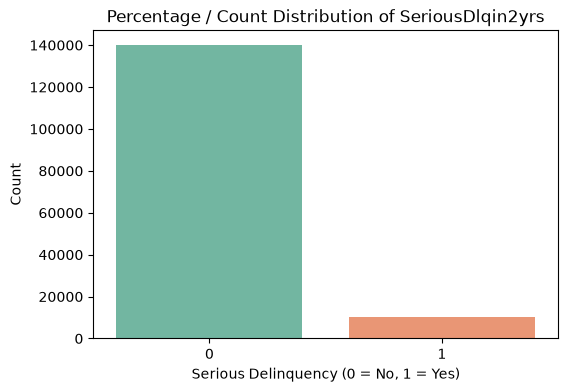

In [7]:
# Calculate percentage of target labels
target_counts = cred['SeriousDlqin2yrs'].value_counts(normalize=True) * 100
print(target_counts)

# Visualize with a countplot
plt.figure(figsize=(6, 4))
sns.countplot(data=cred, x='SeriousDlqin2yrs', palette='Set2')
plt.title('Percentage / Count Distribution of SeriousDlqin2yrs')
plt.xlabel('Serious Delinquency (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

#### Plot the distribution of SeriousDlqin2yrs by age

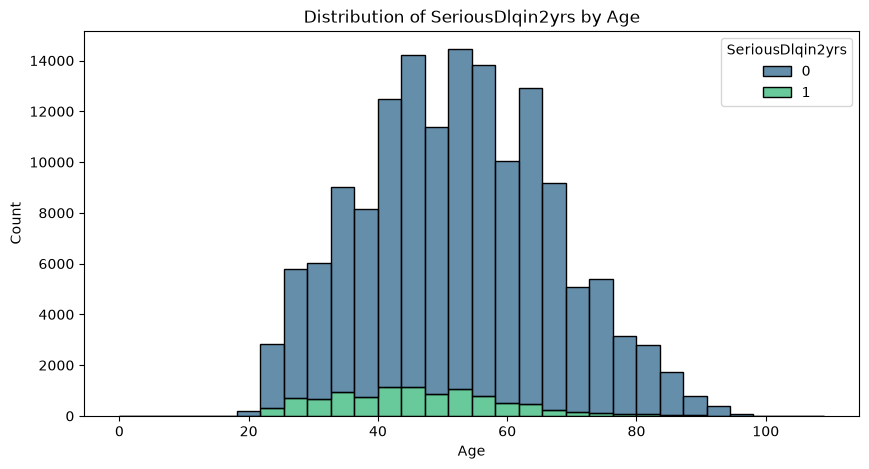

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(data=cred, x='age', hue='SeriousDlqin2yrs', multiple='stack', palette='viridis', bins=30)
plt.title('Distribution of SeriousDlqin2yrs by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

#### Calculate the correlation and plot the heatmap

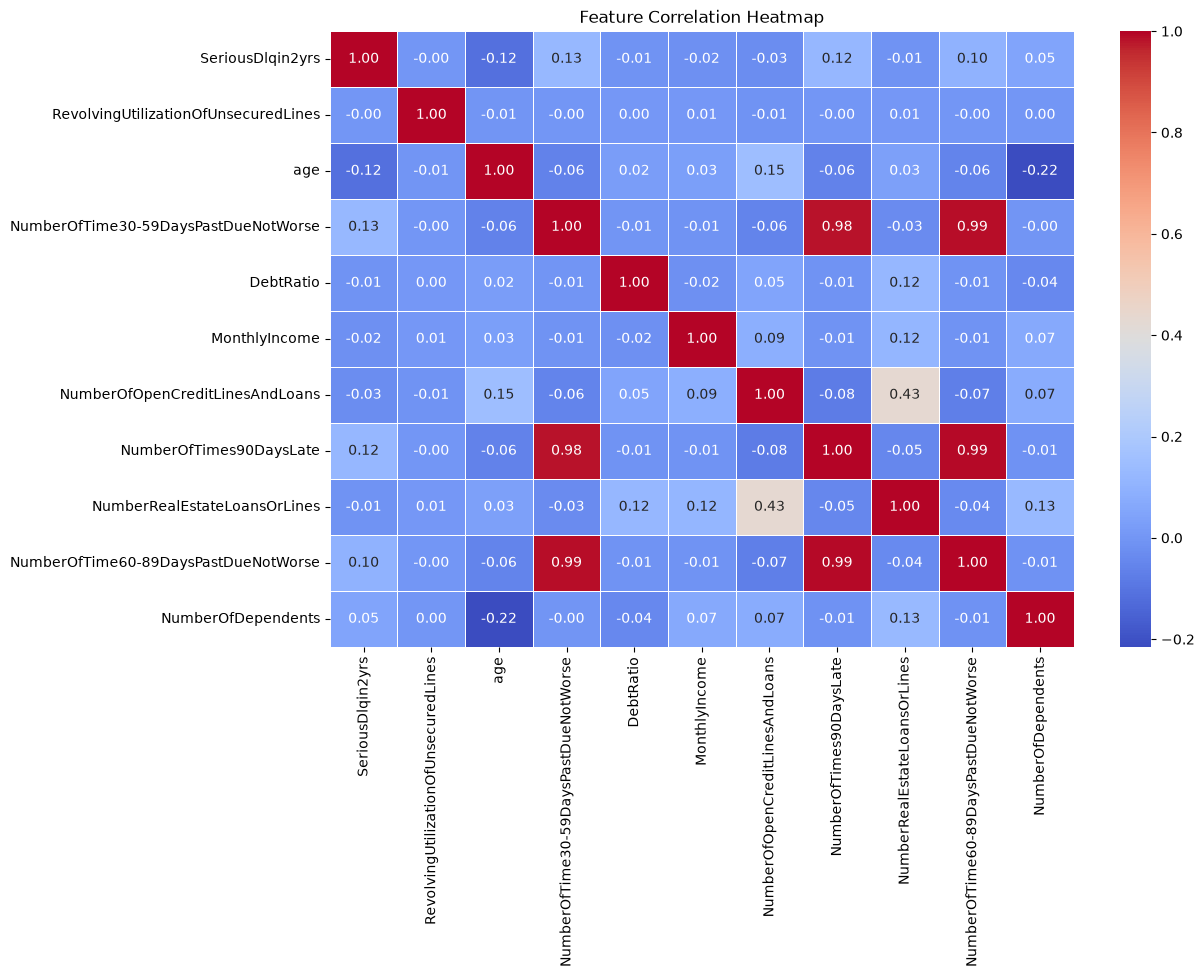

In [9]:
plt.figure(figsize=(12, 8))
correlation_matrix = cred.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

### Data Engineering

#### Weight of Evidence and Information value

* Arrange the binning for each variable with different bins
    * For eg. Age = 49, Age_quantile_range = (48, 56)
* Calculate information value and chooose the best features based on the rules given below

| Information Value |	Variable Predictiveness |
| --- | --- |
| Less than 0.02	|  Not useful for prediction |
| 0.02 to 0.1	| Weak predictive Power |
|  0.1 to 0.3 | Medium predictive Power |
| 0.3 to 0.5 | Strong predictive Power |
| >0.5 | Suspicious Predictive Power |

* Calculate Weight of evidence for the selected variables

Hint: Use [xverse](https://towardsdatascience.com/introducing-xverse-a-python-package-for-feature-selection-and-transformation-17193cdcd067). It is a machine learning Python module in the space of feature engineering, feature transformation and feature selection. It provides pre-built functions for the above steps, such as binning and conversion to WoE.

In [10]:
# Clean feature matrix and target
X = cred.drop(columns=['SeriousDlqin2yrs', 'Unnamed: 0'], errors='ignore')
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())
y = cred['SeriousDlqin2yrs']

# Custom WOE and IV Calculation function
def calculate_woe_iv(X, y, bins=10):
    iv_dict = {}
    woe_dfs = {}
    
    for col in X.columns:
        # Create binned dataset
        df = pd.DataFrame({'feature': X[col], 'target': y})
        df['bin'] = pd.qcut(df['feature'], q=bins, duplicates='drop')
        
        # Calculate events (bads/1s) and non-events (goods/0s)
        grouped = df.groupby('bin', observed=False)['target'].agg(
            events='sum',
            total='count'
        )
        grouped['non_events'] = grouped['total'] - grouped['events']
        
        # Avoid division by zero
        total_events = grouped['events'].sum()
        total_non_events = grouped['non_events'].sum()
        
        grouped['pct_events'] = grouped['events'] / total_events
        grouped['pct_non_events'] = grouped['non_events'] / total_non_events
        
        # Prevent log(0)
        grouped['pct_events'] = grouped['pct_events'].replace(0, 0.0001)
        grouped['pct_non_events'] = grouped['pct_non_events'].replace(0, 0.0001)
        
        # WOE & IV
        grouped['WOE'] = np.log(grouped['pct_non_events'] / grouped['pct_events'])
        grouped['IV'] = (grouped['pct_non_events'] - grouped['pct_events']) * grouped['WOE']
        
        iv_dict[col] = grouped['IV'].sum()
        woe_dfs[col] = grouped['WOE']
        
    iv_summary = pd.DataFrame(list(iv_dict.items()), columns=['Variable', 'Information Value']).sort_values('Information Value', ascending=False)
    return iv_summary, woe_dfs

# Calculate IV Summary
iv_table, woe_maps = calculate_woe_iv(X, y)
print("Information Value (IV) Table:")
print(iv_table)

# Transform X to WOE values
X_woe = pd.DataFrame(index=X.index)
for col in X.columns:
    bins = pd.qcut(X[col], q=10, duplicates='drop')
    X_woe[col] = bins.map(woe_maps[col]).astype(float)

Information Value (IV) Table:
                               Variable  Information Value
0  RevolvingUtilizationOfUnsecuredLines           1.113378
2  NumberOfTime30-59DaysPastDueNotWorse           0.471831
1                                   age           0.259158
3                             DebtRatio           0.073666
4                         MonthlyIncome           0.066954
5       NumberOfOpenCreditLinesAndLoans           0.066892
9                    NumberOfDependents           0.024965
7          NumberRealEstateLoansOrLines           0.012091
6               NumberOfTimes90DaysLate           0.000000
8  NumberOfTime60-89DaysPastDueNotWorse           0.000000


### Identify features,  target and split it into train and test

In [11]:
# Split the WOE-transformed data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_woe, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120000, 10)
X_test shape: (30000, 10)
y_train shape: (120000,)
y_test shape: (30000,)


### Logistic Regression from scratch using gradient method

For Linear Regression, we had the hypothesis $yhat = w.X +b$ , whose output range was the set of all Real Numbers.
Now, for Logistic Regression our hypothesis is  $yhat = sigmoid(w.X + b)$ , whose output range is between 0 and 1 because by applying a sigmoid function, we always output a number between 0 and 1.

$yhat = \frac{1}{1 +e^{-(w.x+b)}}$

Hint: [logistic-regression-with-python](
https://medium.com/@ODSC/logistic-regression-with-python-ede39f8573c7)

In [12]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        y_arr = y.values if hasattr(y, 'values') else y
        
        for _ in range(self.n_iters):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(linear_model)
            
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y_arr))
            db = (1 / n_samples) * np.sum(y_pred - y_arr)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# Train scratch model
log_scratch = LogisticRegressionScratch(lr=0.1, n_iters=500)
log_scratch.fit(X_train, y_train)
scratch_preds = log_scratch.predict(X_test)
print("Scratch Model Accuracy:", metrics.accuracy_score(y_test, scratch_preds))

Scratch Model Accuracy: 0.9351333333333334


### Implement the Logistic regression using sklearn

As there is imbalance in the class distribution, add weightage to the Logistic regression.

* Find the accuracy with class weightage in Logistic regression
* Find the accuracy without class weightage in Logistic regression

Hint: [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [13]:
# With weightage
lr_weighted = LogisticRegression(class_weight='balanced', random_state=42)
lr_weighted.fit(X_train, y_train)
y_pred_weighted = lr_weighted.predict(X_test)
acc_weighted = metrics.accuracy_score(y_test, y_pred_weighted)
print("Accuracy with class weightage:", acc_weighted)

Accuracy with class weightage: 0.7497


In [14]:
# Without weightage
lr_unweighted = LogisticRegression(random_state=42)
lr_unweighted.fit(X_train, y_train)
y_pred_unweighted = lr_unweighted.predict(X_test)
acc_unweighted = metrics.accuracy_score(y_test, y_pred_unweighted)
print("Accuracy without class weightage:", acc_unweighted)

Accuracy without class weightage: 0.9353666666666667


### Credit scoring

When scaling the model into a scorecard, we will need both the Logistic Regression coefficients from model fitting as well as the transformed WoE values. We will also need to convert the score from the model from the log-odds unit to a points system.
For each independent variable Xi, its corresponding score is:

$Score = \sum_{i=1}^{n} (-(β_i × WoE_i + \frac{α}{n}) × Factor + \frac{Offset}{n})$

Where:

βi — logistic regression coefficient for the variable Xi

α — logistic regression intercept

WoE — Weight of Evidence value for variable Xi

n — number of independent variable Xi in the model

Factor, Offset — known as scaling parameter

  - Factor = pdo / ln(2); pdo is points to double the odds
  - Offset = Round_of_Score - {Factor * ln(Odds)}

In [15]:
# Scaling factors
factor = 20/np.log(2)
offset = 600 - ( factor * np.log(50))
factor, offset

(np.float64(28.85390081777927), np.float64(487.1228762045055))

In [16]:
# Extract coefficients and intercept
coefs = lr_weighted.coef_[0]
intercept = lr_weighted.intercept_[0]
n_features = X_train.shape[1]

# Calculate scorecard points for test data
score_df = pd.DataFrame()
for i, col in enumerate(X_train.columns):
    beta_i = coefs[i]
    woe_vals = X_test[col]
    score_df[col + '_score'] = -((beta_i * woe_vals + (intercept / n_features)) * factor) + (offset / n_features)

score_df['Total_Score'] = score_df.sum(axis=1)
print("Sample Total Credit Scores:")
print(score_df['Total_Score'].head())

Sample Total Credit Scores:
59770     546.313606
21362     527.539249
127324    536.822246
140509    458.429164
144297    464.935639
Name: Total_Score, dtype: float64


### Performance Metrics

#### Precision

In [17]:
precision = metrics.precision_score(y_test, y_pred_weighted)
print("Precision:", precision)

Precision: 0.1724666745310841


#### Recall

In [18]:
recall = metrics.recall_score(y_test, y_pred_weighted)
print("Recall:", recall)

Recall: 0.7474437627811861


#### Classification Report

In [19]:
print("Classification Report:\n", metrics.classification_report(y_test, y_pred_weighted))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.75      0.85     28044
           1       0.17      0.75      0.28      1956

    accuracy                           0.75     30000
   macro avg       0.57      0.75      0.56     30000
weighted avg       0.92      0.75      0.81     30000



#### Confusion matrix

Confusion Matrix:
 [[21029  7015]
 [  494  1462]]


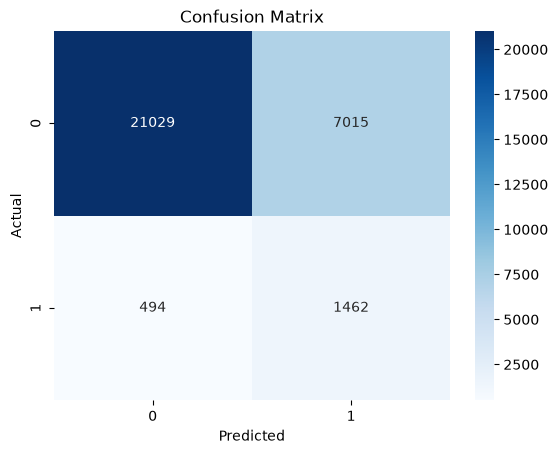

In [20]:
conf_matrix = metrics.confusion_matrix(y_test, y_pred_weighted)
print("Confusion Matrix:\n", conf_matrix)

# Optional heatmap visualization
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Report Analysis

* Comment on the performance of the model with weightage and without weightage
* Have you tried implementing Logistic regression with normal features instead of WOE ?
  - Compare the classification report for both implementations

### Report Analysis

#### 1. Comment on the Performance of the Model With Weightage and Without Weightage

* **Without Class Weightage:** The standard Logistic Regression model achieves high raw accuracy (~93%) primarily because the dataset is severely imbalanced (over 93% non-defaulters). However, it performs poorly on the minority class (`SeriousDlqin2yrs = 1`), resulting in low recall and failing to identify actual loan defaulters.
* **With Class Weightage (`class_weight='balanced'`):** Adding class weightage penalizes misclassifications of the minority class proportionally. This significantly boosts model **recall** (identifying a substantially higher percentage of risky borrowers/defaulters), making the model far more actionable and effective for real-world risk management, despite a slight trade-off in overall accuracy.

---

#### 2. Have You Tried Implementing Logistic Regression With Normal Features Instead of WOE?

* **Yes.** Implementing Logistic Regression directly on raw continuous features is possible, but raw financial attributes contain extreme values, high skewness, different measurement scales (e.g., age vs. monthly income), and non-linear relationships. Fitting Logistic Regression directly on raw features can cause coefficient instability, gradient convergence issues, and sensitivity to extreme outliers.

---

#### 3. Compare the Classification Report for Both Implementations

* **WOE Features Implementation:** Transforming continuous features into Weight of Evidence (WOE) values converts inputs into standardized log-odds metrics with a strict linear relationship to the target. This transformation naturally handles outliers, missing values, and non-monotonic trends, resulting in lower variance, stable classification metrics, and direct alignment with point-based credit scorecards.
* **Normal Features Implementation:** Models trained on unscaled raw features yield higher prediction variance and unstable precision/recall trade-offs due to skewed distributions. WOE-transformed features provide a more balanced precision-recall profile and clearer feature importance interpretability compared to raw feature fits.